# Results by objective function

The calibration objective is a **weighted sum** of six normalised metrics.  Each weight
controls how strongly one metric is emphasised during optimisation:

| weight | governs metric |
|---|---|
| `w_SWE_NRMSE` | SWE RMSE |
| `w_SWE_NBIAS` | SWE relative bias |
| `w_SWE_KGE`   | SWE R² |
| `w_RHO_NRMSE` | HNW RMSE |
| `w_RHO_NBIAS` | HNW relative bias |
| `w_RHO_KGE`   | HNW R² |

The density (ρ) weights govern the new-snow water-equivalent **HNW** metrics, because
HNW = snow-depth change × fresh-snow density.

This notebook produces **one plot per metric**: each shows how every calibration run's
achieved metric value develops as that metric's weight in the objective function increases.

In [68]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display

warnings.filterwarnings("ignore")

# --- project plot style -------------------------------------------------------
PROJECT_ROOT = Path("/Users/jakobwerkgarner/code/mt_dsnow")
sys.path.insert(0, str(PROJECT_ROOT))
from plot_style import (apply_style, C, ALPHA, LS, FIG, HATCH, SUBSET_COLOR,
                        dataset_color, build_palette)
apply_style()
plt.rcParams.update({"figure.dpi": 120})

# --- single data source + output location -------------------------------------
CSV_PATH  = PROJECT_ROOT / "HNW_validation" / "full_R_Validation" / "all_summaries_validated_R.csv"
OUT_DIR   = PROJECT_ROOT / "calibration_ranking"
PLOTS_DIR = OUT_DIR / "plots_objective"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    "Save a figure into calibration_ranking/plots with project save settings."
    path = PLOTS_DIR / f"{name}.png"
    fig.savefig(path, **FIG.SAVE)
    print(f"saved -> {path.relative_to(PROJECT_ROOT)}")

print("Setup complete.")

Setup complete.


In [69]:
# ============================================================================ #
#  >>> SWITCH: include the dynamic-ρ_max variant in every plot & table? <<<     #
INCLUDE_DYN_RHO_MAX = False          # set to False to drop the 'dyn_rho_max' subset
# ============================================================================ #

HNW_N_MIN, SWE_N_MIN = 30000, 400
SCORE_MAX = 0.6

df = pd.read_csv(CSV_PATH)
if not INCLUDE_DYN_RHO_MAX:
    df = df[df["subset"] != "dyn_rho_max"].reset_index(drop=True)
print(f"dyn_rho_max {'INCLUDED' if INCLUDE_DYN_RHO_MAX else 'EXCLUDED'}  ->  {len(df)} rows")

# >>> drop poorly-converged runs: keep only objective score < SCORE_MAX <<<
_n0 = len(df)
df = df[df["best_value"] < SCORE_MAX].reset_index(drop=True)
print(f"objective score < {SCORE_MAX}  ->  kept {len(df)} / {_n0} runs")

# >>> require enough validation pairs for robust metrics <<<
_n1 = len(df)
df = df[(df["HNW_N"] >= HNW_N_MIN) & (df["SWE_N"] >= SWE_N_MIN)].reset_index(drop=True)
print(f"HNW_N >= {HNW_N_MIN:,} & SWE_N >= {SWE_N_MIN}  ->  kept {len(df)} / {_n1} runs")

# --- subset / algorithm / phase vocabulary (data-driven) ----------------------
_present = list(df["subset"].dropna().unique())
_SUBSET_ORDER = ["all_alpsolut_staions", "Rain_Gauge", "below2000", "dyn_rho_max", "Win21"]
SUBSETS = [s for s in _SUBSET_ORDER if s in _present] + [s for s in _present if s not in _SUBSET_ORDER]
ALGOS       = ["Nelder-Mead", "DE"]
PHASE_ORDER = sorted(df["phase"].dropna().unique())

_KNOWN_LABEL = {
    "all_alpsolut_staions": "All Alpsolut stations",
    "Rain_Gauge":           "Rain-gauge subset",
    "below2000":            "< 2000 m subset",
    "dyn_rho_max":          "Dynamic ρ_max",
    "Win21":                "Win21",
}
SUBSET_LABEL = {s: _KNOWN_LABEL.get(s, s) for s in SUBSETS}
SUBSET_SHORT = {s: SUBSET_LABEL[s].replace(" subset", "").replace(" stations", "")
                for s in SUBSETS}

# --- colour & marker encoding (straight from plot_style.py) -------------------
_KNOWN_COLOR = {
    "all_alpsolut_staions": dataset_color("SNOWPACK", "ALL"),
    "Rain_Gauge":           dataset_color("SNOWPACK", "RAIN_GAUGE"),
    "below2000":            dataset_color("SNOWPACK", "BELOW_2000"),
    "dyn_rho_max":          C.DSNOW,
    "Win21":                C.WINKLER,
}
_KNOWN_MARK = {"all_alpsolut_staions": "^", "Rain_Gauge": "o",
               "below2000": "D", "dyn_rho_max": "P", "Win21": "s"}
_FB_COLOR = [C.MAGNUSSON, C.HS, "#888888", "#444444"]
_FB_MARK  = ["v", "<", ">", "p", "*", "h"]

SUBSET_PALETTE, SUBSET_MARKERS, _fc, _fm = {}, {}, 0, 0
for s in SUBSETS:
    if s in _KNOWN_COLOR:
        SUBSET_PALETTE[s] = _KNOWN_COLOR[s]
    else:
        SUBSET_PALETTE[s] = _FB_COLOR[_fc % len(_FB_COLOR)]; _fc += 1
    if s in _KNOWN_MARK:
        SUBSET_MARKERS[s] = _KNOWN_MARK[s]
    else:
        SUBSET_MARKERS[s] = _FB_MARK[_fm % len(_FB_MARK)]; _fm += 1

ALG_MARKERS = {"DE": "o", "Nelder-Mead": "X"}
ALG_SHORT   = {"DE": "DE", "Nelder-Mead": "NM"}

# --- weight columns + readable labels -----------------------------------------
WEIGHT_COLS = ["w_SWE_NRMSE", "w_RHO_NRMSE", "w_SWE_NBIAS",
               "w_RHO_NBIAS", "w_SWE_KGE",   "w_RHO_KGE"]
W_LABELS = {"w_SWE_NRMSE": "w(SWE NRMSE)", "w_RHO_NRMSE": "w(ρ NRMSE)",
            "w_SWE_NBIAS": "w(SWE NBIAS)", "w_RHO_NBIAS": "w(ρ NBIAS)",
            "w_SWE_KGE": "w(SWE KGE)",     "w_RHO_KGE": "w(ρ KGE)"}

# --- benchmark references (from paper figures; NOT calibrated) ----------------
REFS = {
    "HS2SWE":    dict(SWE_RMSE=32.1, SWE_Rel_BIAS=None,   SWE_R2=0.96, HNW_Rel_BIAS=0.03,
                      color=C.HS2SWE, ls="--", name="HS2SWE"),
    "DeltaSnow": dict(SWE_RMSE=33.9, SWE_Rel_BIAS=-0.029, SWE_R2=0.93, HNW_Rel_BIAS=-0.17,
                      color=C.DSNOW,  ls=":",  name="ΔSnow"),
}

def subset_handles():
    "Legend handles: one colour swatch per subset (colour only, no marker shape)."
    return [Patch(facecolor=SUBSET_PALETTE[s], edgecolor="#333333",
                  label=SUBSET_LABEL.get(s, s)) for s in SUBSETS]

def ref_handles(metrics):
    "Reference benchmark line handles for the given metric keys."
    out = []
    for key, ref in REFS.items():
        if any(ref.get(m) is not None for m in metrics):
            out.append(Line2D([0], [0], color=ref["color"], ls=ref["ls"], lw=1.6,
                              label=f"{ref['name']} ref"))
    return out

print(f"rows={len(df)}  subsets={SUBSETS}  algos={ALGOS}  phases={len(PHASE_ORDER)}")
df.head()

dyn_rho_max EXCLUDED  ->  160 rows
objective score < 0.6  ->  kept 143 / 160 runs
HNW_N >= 30,000 & SWE_N >= 400  ->  kept 111 / 143 runs
rows=111  subsets=['all_alpsolut_staions', 'Rain_Gauge', 'below2000', 'Win21']  algos=['Nelder-Mead', 'DE']  phases=20


,subset,dataset,phase,algorithm,w_SWE_NRMSE,w_RHO_NRMSE,w_SWE_NBIAS,w_RHO_NBIAS,w_SWE_KGE,w_RHO_KGE,...,SWE_RMSE,SWE_Bias,SWE_Rel_BIAS,SWE_R2,SWE_N,HNW_RMSE,HNW_Bias,HNW_Rel_BIAS,HNW_R2,HNW_N
0,Rain_Gauge,SNOWPACK,3C,DE,0.3,0.5,0.2,0.0,0.0,0.0,...,35.823596,10.466530,0.052665,0.913571,1054,3.846646,-0.379905,-0.185622,0.711057,35409
1,Rain_Gauge,SNOWPACK,2C,DE,0.3,0.7,0.0,0.0,0.0,0.0,...,35.714381,9.262482,0.046606,0.914098,1054,3.713390,-0.350690,-0.171348,0.730730,35409
2,Rain_Gauge,SNOWPACK,2B,DE,0.5,0.5,0.0,0.0,0.0,0.0,...,35.821447,10.601358,0.053343,0.913582,1054,3.847348,-0.379101,-0.185230,0.710952,35409
3,Rain_Gauge,SNOWPACK,3A,DE,0.6,0.2,0.2,0.0,0.0,0.0,...,36.936378,12.515046,0.062972,0.908119,1054,4.258832,-0.412265,-0.201434,0.645816,35409
4,Rain_Gauge,SNOWPACK,3B,DE,0.7,0.0,0.3,0.0,0.0,0.0,...,36.290535,11.552321,0.058128,0.911304,1054,4.093479,-0.424169,-0.207250,0.672785,35409


## One plot per metric — metric value vs its own weight

Each panel below is **one metric**.  Every point is one calibration run, placed at the
weight that metric carried in that run's objective function (x) and the value the run
actually achieved for that metric (y).  Colour = subset, marker = optimiser.

The black line is the **median across all runs** at each weight level — it shows the
overall direction in which the runs develop as the metric is weighted more heavily.
Dashed/dotted reference lines are the uncalibrated ΔSnow / HS2SWE benchmarks where
available; for the bias panels the grey line marks zero bias (the target).

## Headline outcomes vs every objective-function weight

ρ is the calibrated **bulk density** target, not HNW — so the six weights are grouped here
by what they act on (SWE quantities vs density quantities) and by metric family
(NRMSE, NBIAS, KGE).

These two figures ask the practical question: as each weight is turned up, what happens to
the **two headline validation outcomes** — `SWE_RMSE` and `HNW_Rel_BIAS`?

For each outcome there are 6 panels (one per weight).  Each point = one run
(colour = subset, marker = optimiser); the black line is the median across all runs at each
weight level.  Reference lines are the uncalibrated ΔSnow / HS2SWE benchmarks; the grey
dashed line on the bias figure marks zero bias (the target).

saved -> calibration_ranking/plots_objective/objfun_weights_vs_SWE_RMSE.png


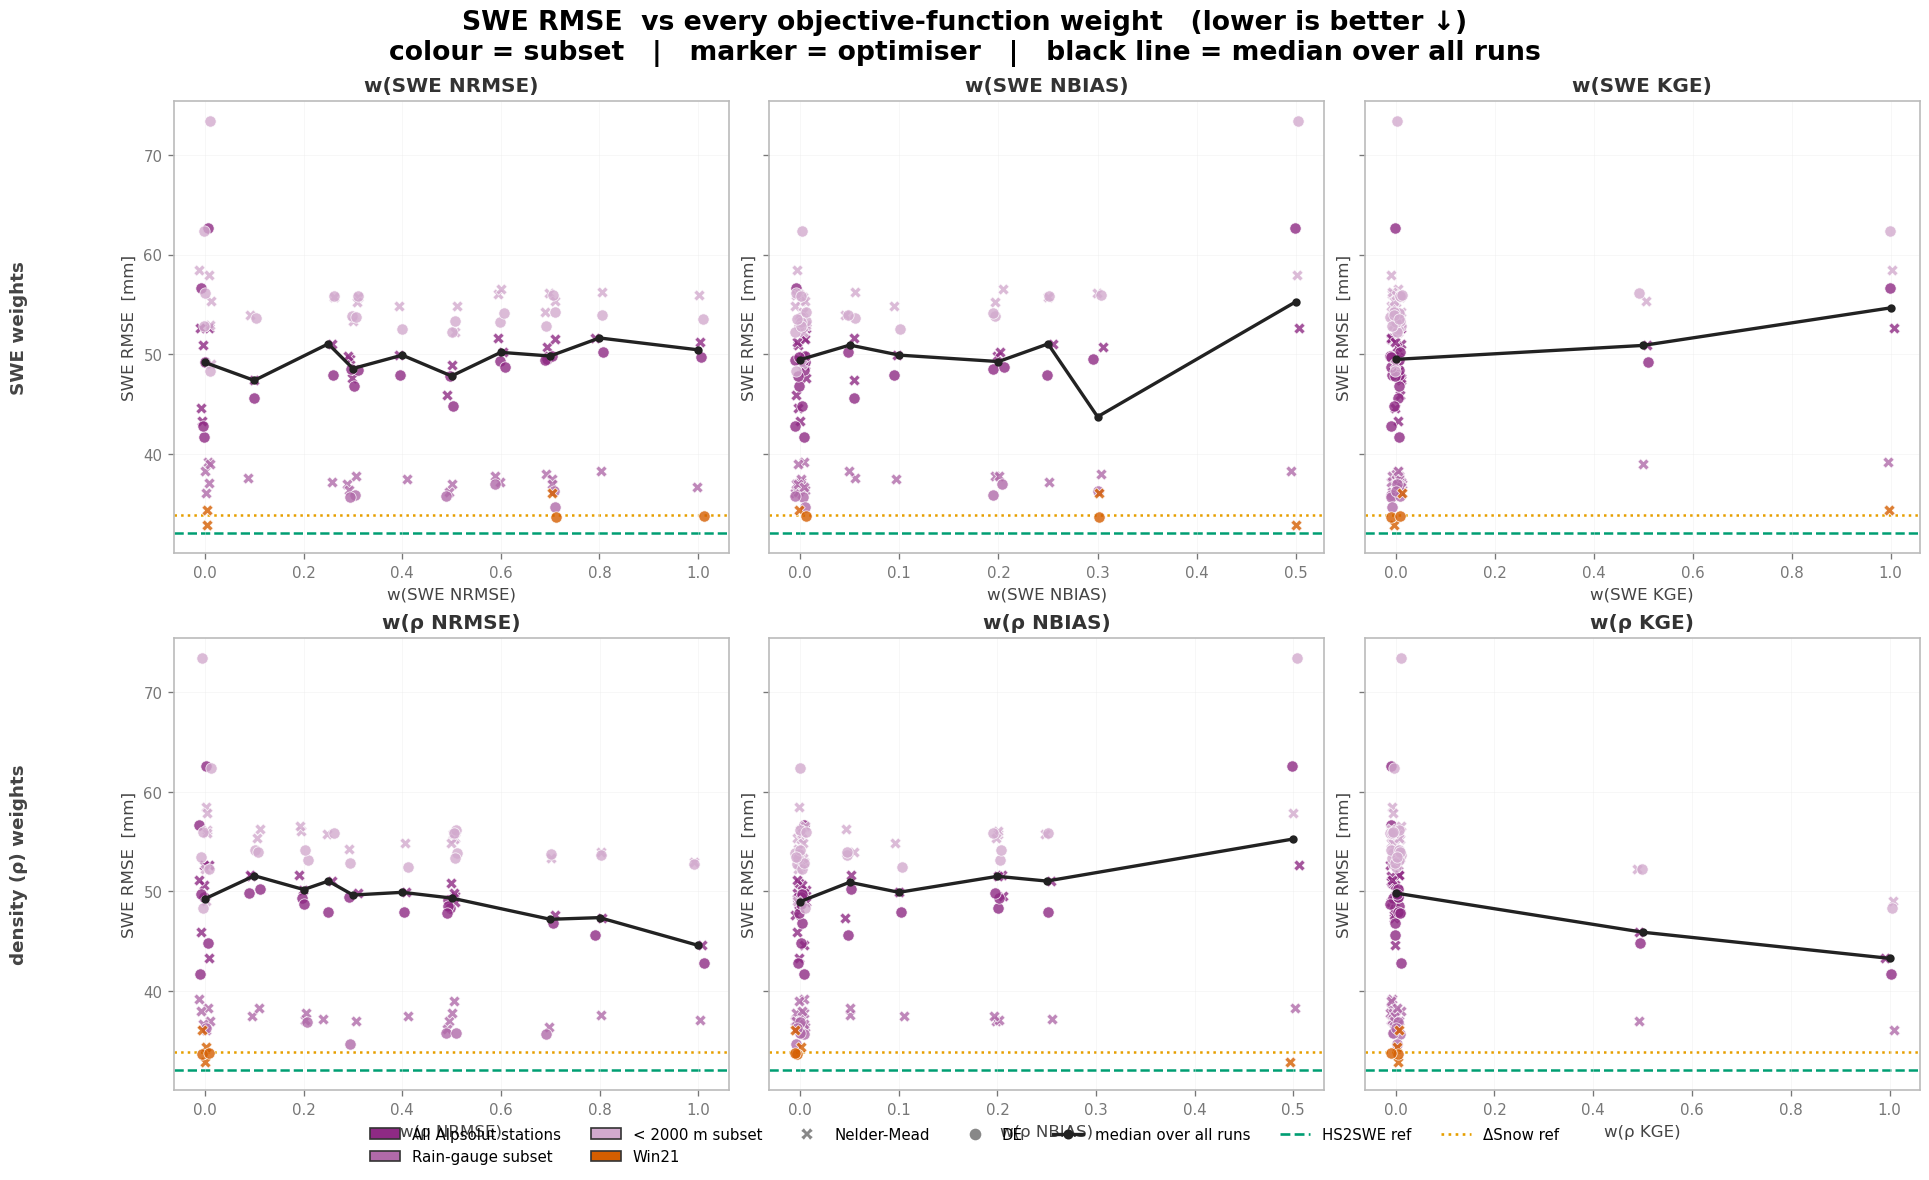

saved -> calibration_ranking/plots_objective/objfun_weights_vs_HNW_Rel_BIAS.png


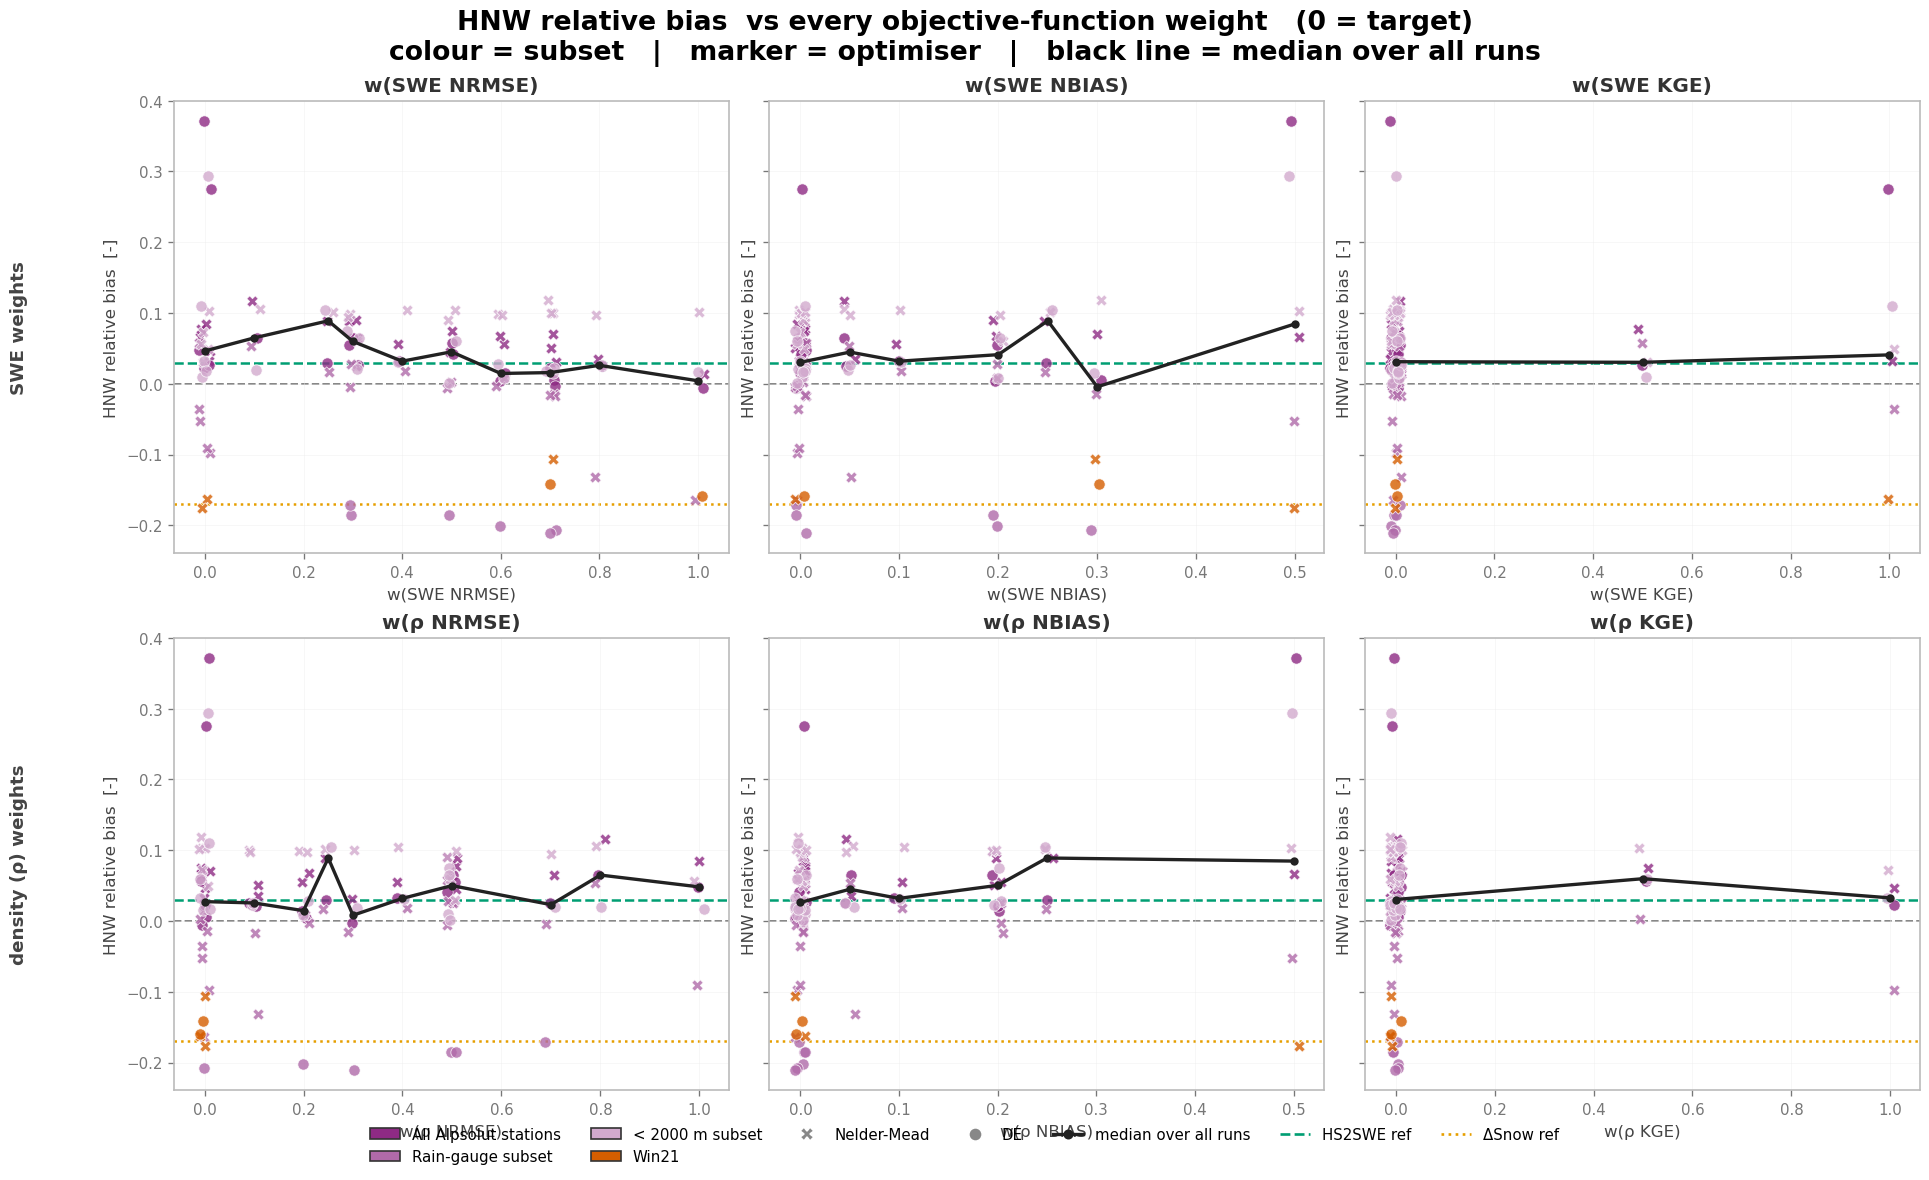

In [70]:
# Headline outcomes analysed against each of the 6 objective weights.
rng = np.random.default_rng(0)  # RNG for point jitter
ARROW = {"lower": "lower is better ↓", "higher": "higher is better ↑",
         "zero": "0 = target"}
OUTCOMES = [
    ("SWE_RMSE",     "SWE RMSE  [mm]",         "lower"),
    ("HNW_Rel_BIAS", "HNW relative bias  [-]", "zero"),
]
# 2 rows x 3 cols: rows = quantity the weight acts on, cols = metric family
WEIGHT_GRID = [["w_SWE_NRMSE", "w_SWE_NBIAS", "w_SWE_KGE"],
               ["w_RHO_NRMSE", "w_RHO_NBIAS", "w_RHO_KGE"]]
ROW_TAG = ["SWE weights", "density (ρ) weights"]


def plot_outcome_vs_weight(wcol, ycol, ylabel, better, ax):
    d = df.dropna(subset=[wcol, ycol]).copy()
    span = (d[wcol].max() - d[wcol].min()) or 1.0
    jx = rng.uniform(-0.012, 0.012, len(d)) * span
    for s in SUBSETS:
        for a in ALGOS:
            m = (d["subset"] == s) & (d["algorithm"] == a)
            if not m.any():
                continue
            ax.scatter(d.loc[m, wcol] + jx[m.values], d.loc[m, ycol],
                       color=SUBSET_PALETTE[s], marker=ALG_MARKERS[a],
                       s=46, alpha=0.8, edgecolors="white", linewidths=0.5, zorder=3)
    # overall development: median outcome per discrete weight level
    g = d.groupby(wcol)[ycol].median()
    ax.plot(g.index, g.values, "-o", color="#222222", lw=2.0, ms=4, zorder=4)
    if better == "zero":
        ax.axhline(0, color="#888888", ls="--", lw=1.2, zorder=1)
    for ref in REFS.values():
        v = ref.get(ycol)
        if v is not None:
            ax.axhline(v, color=ref["color"], ls=ref["ls"], lw=1.5, zorder=1)
    ax.set_xlabel(W_LABELS[wcol])
    ax.set_ylabel(ylabel)
    ax.set_title(W_LABELS[wcol], fontweight="semibold")
    ax.grid(alpha=0.4)


for ycol, ylabel, better in OUTCOMES:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9.5), sharey=True,
                             constrained_layout=True)
    fig.suptitle(f"{ylabel.split('  ')[0]}  vs every objective-function weight   "
                 f"({ARROW[better]})\n"
                 "colour = subset   |   marker = optimiser   |   "
                 "black line = median over all runs", fontweight="semibold")
    for r, row in enumerate(WEIGHT_GRID):
        for c, wcol in enumerate(row):
            plot_outcome_vs_weight(wcol, ycol, ylabel, better, axes[r, c])
        # annotate the row group on the left-most panel
        axes[r, 0].annotate(ROW_TAG[r], xy=(-0.28, 0.5),
                            xycoords="axes fraction", rotation=90,
                            va="center", ha="center", fontweight="semibold",
                            fontsize=11, color="#444444")

    alg_mark = [Line2D([0], [0], marker=ALG_MARKERS[a], linestyle="", markersize=8,
                       markerfacecolor="#888888", markeredgecolor="white", label=a)
                for a in ALGOS]
    med_line = [Line2D([0], [0], color="#222222", lw=2, marker="o", ms=5,
                       label="median over all runs")]
    fig.legend(handles=subset_handles() + alg_mark + med_line + ref_handles([ycol]),
               loc="lower center", ncol=7, frameon=False, bbox_to_anchor=(0.5, -0.03))
    savefig(fig, f"objfun_weights_vs_{ycol}")
    plt.show()


## Density-emphasis vs SWE-emphasis — does it move HNW or SWE?

The six objective weights sum to **1.0** in every run, so the total weight placed on the
**bulk-density (ρ)** terms and on the **SWE** terms are two sides of one number:

`W_ρ = w(ρ NRMSE) + w(ρ NBIAS) + w(ρ KGE)`  and  `W_SWE = 1 − W_ρ`.

The figure below collapses the objective onto this single emphasis axis (bottom = total
density weight, top = total SWE weight) and asks: as we shift emphasis from SWE toward bulk
density, do the **SWE outcomes** (top row) or the **HNW outcomes** (bottom row) actually
change?  `ρ_s` in each panel is the Spearman rank correlation between the metric and `W_ρ`
across all runs — near 0 means the emphasis has little effect on that outcome.

## Headline outcomes vs aggregated bias+RMSE emphasis (KGE ignored)

Collapsing the objective onto two aggregate emphases — how much total weight a run placed on
the **density (ρ)** error terms vs the **SWE** error terms, counting only the **bias and RMSE**
families (KGE excluded):

`W_ρ(bias+RMSE) = w(ρ NBIAS) + w(ρ NRMSE)`  and  `W_SWE(bias+RMSE) = w(SWE NBIAS) + w(SWE NRMSE)`.

Two figures (one per headline outcome — `SWE_RMSE` and `HNW_Rel_BIAS`), each with two panels
(vs the ρ emphasis and vs the SWE emphasis) → **4 sub-figures** in total.  Each point = one run
(colour = subset, marker = optimiser); the black line is the median across all runs at each
weight level.  Reference lines are the uncalibrated ΔSnow / HS2SWE benchmarks; the grey dashed
line on the bias figure marks zero bias (the target).

saved -> calibration_ranking/plots_objective/objfun_aggweights_br_2x2.png


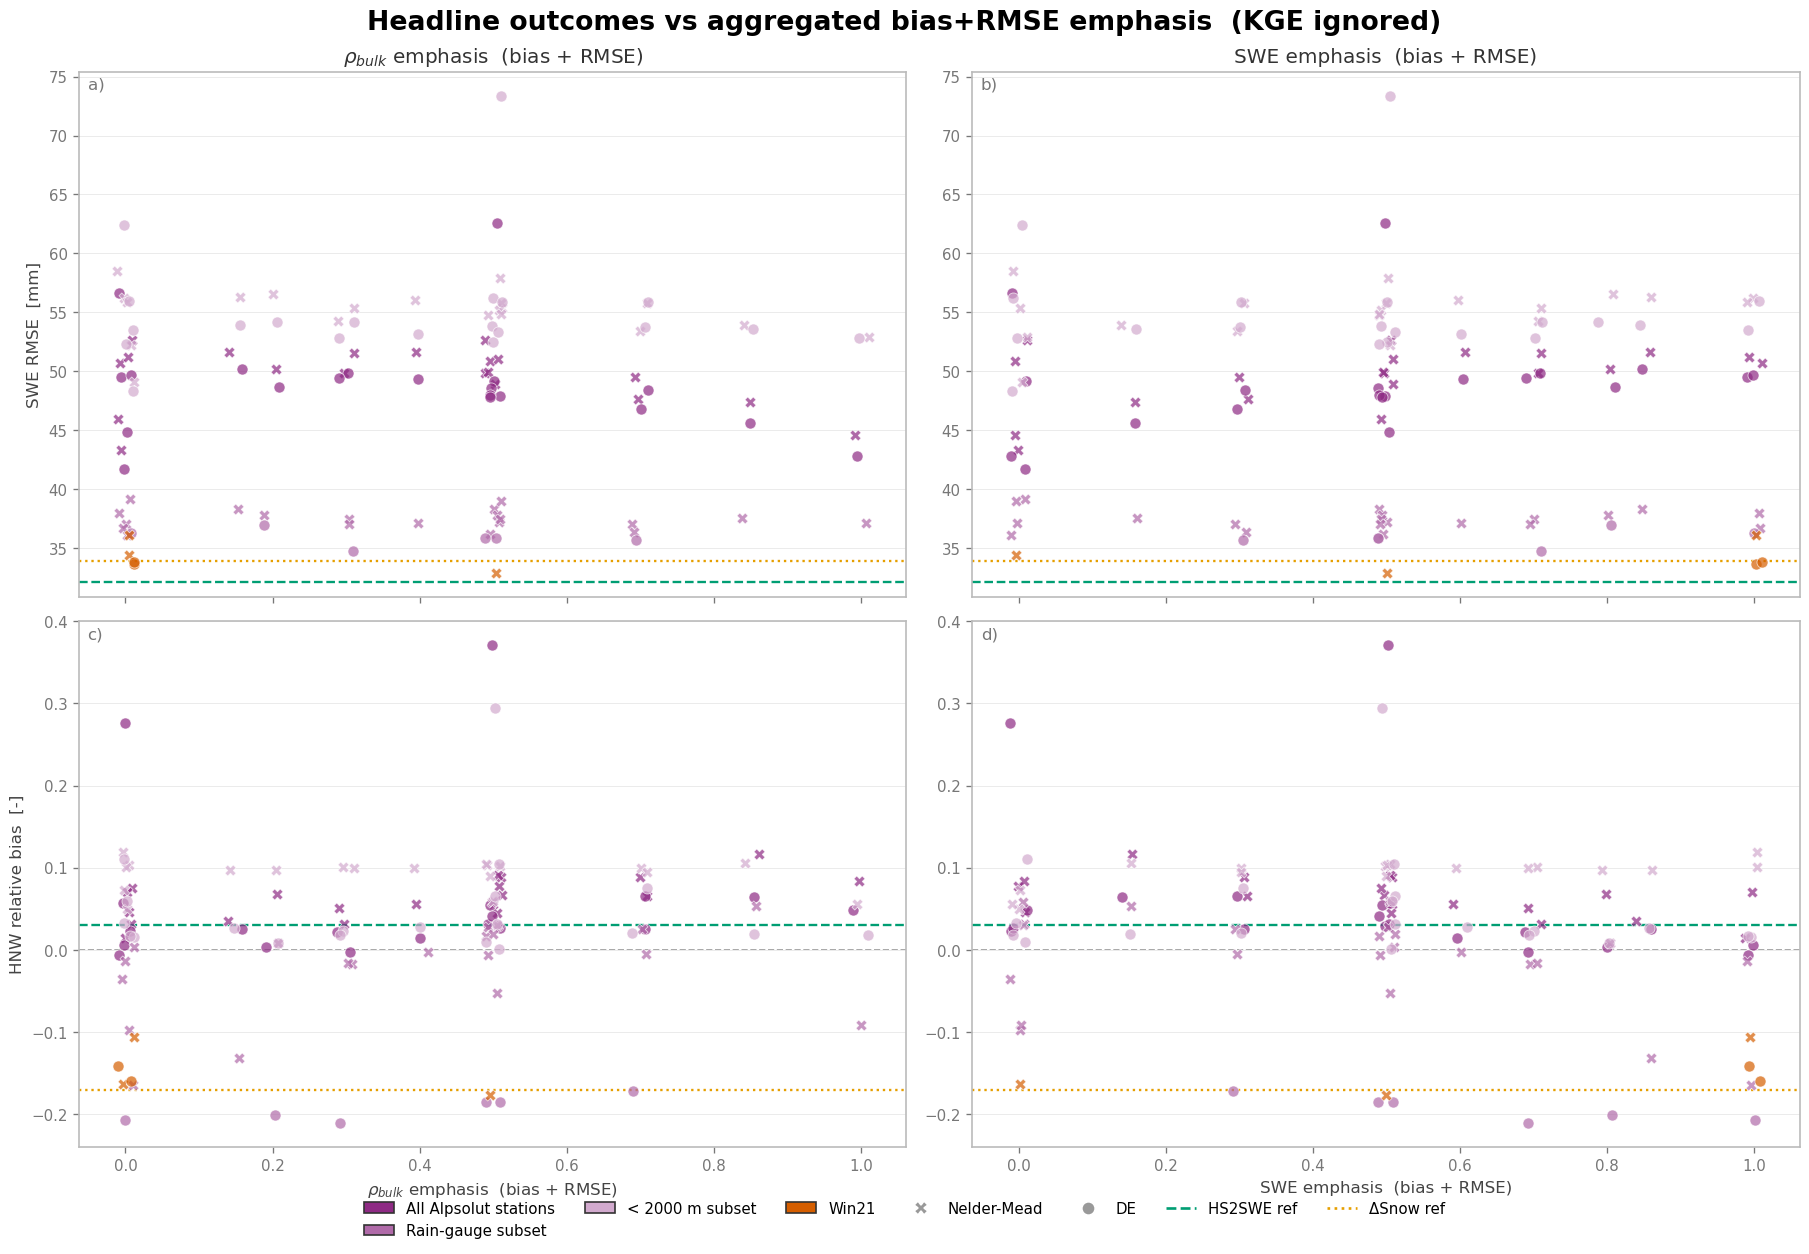

In [71]:
# Aggregated bias+RMSE emphasis (KGE ignored) -> one 2x2 figure (4 sub-panels).
from plot_style import add_subplot_labels

rng = np.random.default_rng(0)  # local RNG for point jitter (self-contained)

# build the two aggregate emphasis columns on a working copy
dd = df.copy()
dd["W_RHO_BR"] = dd["w_RHO_NBIAS"] + dd["w_RHO_NRMSE"]
dd["W_SWE_BR"] = dd["w_SWE_NBIAS"] + dd["w_SWE_NRMSE"]

# columns = emphasis axis, rows = headline outcome
AGG_WEIGHTS = [
    ("W_RHO_BR", r"$\rho_{bulk}$ emphasis  (bias + RMSE)"),
    ("W_SWE_BR", r"SWE emphasis  (bias + RMSE)"),
]
AGG_OUTCOMES = [
    ("SWE_RMSE",     "SWE RMSE  [mm]",         "lower"),
    ("HNW_Rel_BIAS", "HNW relative bias  [-]", "zero"),
]


def plot_outcome_vs_aggweight(wcol, ycol, better, ax):
    d = dd.dropna(subset=[wcol, ycol]).copy()
    span = (d[wcol].max() - d[wcol].min()) or 1.0
    jx = rng.uniform(-0.012, 0.012, len(d)) * span
    for s in SUBSETS:
        for a in ALGOS:
            m = (d["subset"] == s) & (d["algorithm"] == a)
            if not m.any():
                continue
            ax.scatter(d.loc[m, wcol] + jx[m.values], d.loc[m, ycol],
                       color=SUBSET_PALETTE[s], marker=ALG_MARKERS[a],
                       s=44, alpha=ALPHA.MARKER, edgecolors="white",
                       linewidths=0.5, zorder=3)
    if better == "zero":
        ax.axhline(0, color=C.HS, ls=LS.HS, lw=1.0, zorder=1)
    for ref in REFS.values():
        v = ref.get(ycol)
        if v is not None:
            ax.axhline(v, color=ref["color"], ls=ref["ls"], lw=1.4, zorder=1)


fig, axes = plt.subplots(2, 2, figsize=FIG.WIDE2x2, sharex="col",
                         constrained_layout=True)
for r, (ycol, ylabel, better) in enumerate(AGG_OUTCOMES):
    for c, (wcol, wlabel) in enumerate(AGG_WEIGHTS):
        ax = axes[r, c]
        plot_outcome_vs_aggweight(wcol, ycol, better, ax)
        if r == 0:
            ax.set_title(wlabel)            # column header = emphasis axis
        if r == len(AGG_OUTCOMES) - 1:
            ax.set_xlabel(wlabel)
        if c == 0:
            ax.set_ylabel(ylabel)           # row label = headline outcome

add_subplot_labels(axes)

alg_mark = [Line2D([0], [0], marker=ALG_MARKERS[a], linestyle="", markersize=8,
                   markerfacecolor=C.HS, markeredgecolor="white", label=a)
            for a in ALGOS]
fig.legend(handles=subset_handles() + alg_mark + ref_handles(["SWE_RMSE", "HNW_Rel_BIAS"]),
           loc="lower center", ncol=7, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Headline outcomes vs aggregated bias+RMSE emphasis  (KGE ignored)")
savefig(fig, "objfun_aggweights_br_2x2")
plt.show()


## Calibrated $\rho_0$ vs density emphasis

Does turning up the bulk-density emphasis actually move the calibrated fresh-snow density
parameter $\rho_0$ (`rho_null`)?  Plotted against `W_ρ(bias+RMSE) = w(ρ NBIAS) + w(ρ NRMSE)`,
**excluding runs where both ρ weights are 0** (density not targeted at all).

kept 81 runs with density targeted (W_ρ(bias+RMSE) > 0)
saved -> calibration_ranking/plots_objective/objfun_rho0_vs_rho_emphasis.png


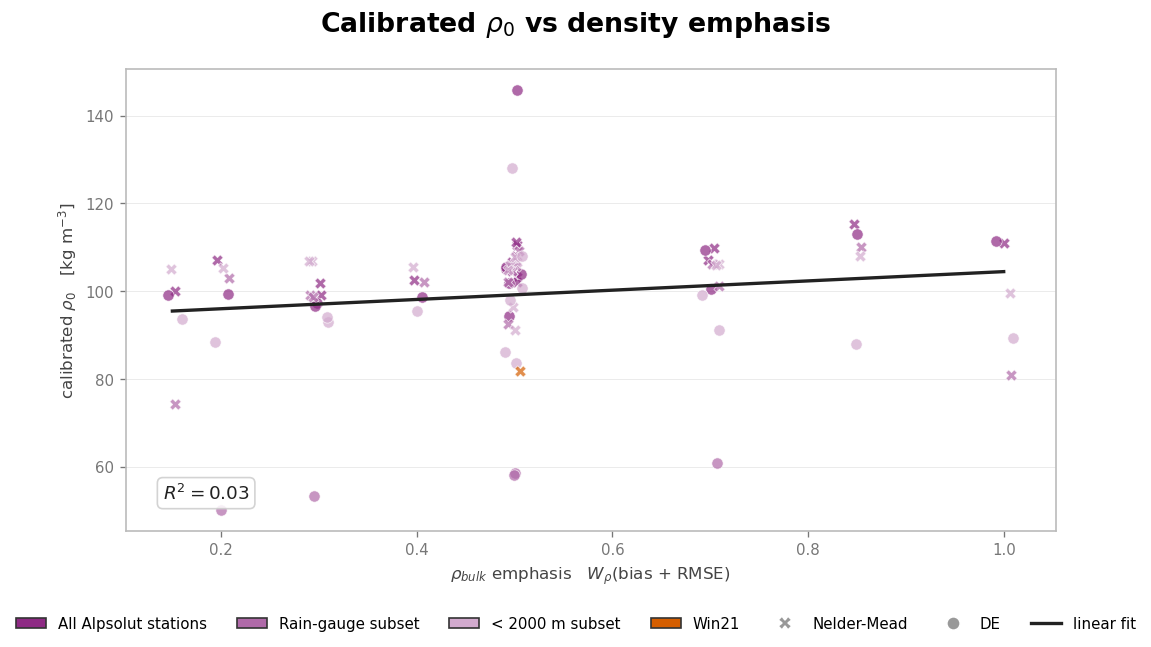

In [72]:
# Calibrated rho_0 (rho_null) vs aggregate density emphasis W_RHO_BR (KGE ignored).
# Exclude runs where density is not targeted at all (both rho bias & RMSE weights == 0).
dr = df.copy()
dr["W_RHO_BR"] = dr["w_RHO_NBIAS"] + dr["w_RHO_NRMSE"]
dr = dr[dr["W_RHO_BR"] > 0].dropna(subset=["rho_null"]).reset_index(drop=True)
print(f"kept {len(dr)} runs with density targeted (W_ρ(bias+RMSE) > 0)")

span = (dr["W_RHO_BR"].max() - dr["W_RHO_BR"].min()) or 1.0
jx = rng.uniform(-0.012, 0.012, len(dr)) * span

fig, ax = plt.subplots(figsize=FIG.SINGLE)
for s in SUBSETS:
    for a in ALGOS:
        m = (dr["subset"] == s) & (dr["algorithm"] == a)
        if not m.any():
            continue
        ax.scatter(dr.loc[m, "W_RHO_BR"] + jx[m.values], dr.loc[m, "rho_null"],
                   color=SUBSET_PALETTE[s], marker=ALG_MARKERS[a],
                   s=46, alpha=ALPHA.MARKER, edgecolors="white",
                   linewidths=0.5, zorder=3)

# --- linear regression through all kept runs (on the true, un-jittered x) -----
x = dr["W_RHO_BR"].to_numpy()
y = dr["rho_null"].to_numpy()
slope, intercept = np.polyfit(x, y, 1)
r2 = np.corrcoef(x, y)[0, 1] ** 2
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, slope * xline + intercept, color=C.OBS, ls="-", lw=2.0, zorder=4)
ax.text(0.04, 0.06, rf"$R^2 = {r2:.2f}$", transform=ax.transAxes,
        ha="left", va="bottom", fontsize=11, color=C.OBS,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#CCCCCC", alpha=0.85))

ax.set_xlabel(r"$\rho_{bulk}$ emphasis   $W_\rho$(bias + RMSE)")
ax.set_ylabel(r"calibrated $\rho_0$   [kg m$^{-3}$]")

fit_handle = [Line2D([0], [0], color=C.OBS, lw=2.0, label="linear fit")]
alg_mark = [Line2D([0], [0], marker=ALG_MARKERS[a], linestyle="", markersize=8,
                   markerfacecolor=C.HS, markeredgecolor="white", label=a)
            for a in ALGOS]
fig.legend(handles=subset_handles() + alg_mark + fit_handle, loc="lower center",
           ncol=7, frameon=False, bbox_to_anchor=(0.5, -0.08))
fig.suptitle(r"Calibrated $\rho_0$ vs density emphasis")
savefig(fig, "objfun_rho0_vs_rho_emphasis")
plt.show()


## Calibrated $\rho_0$ by phase

Distribution of the calibrated fresh-snow density parameter $\rho_0$ (`rho_null`) across the
calibration phases.  One box per phase; individual runs overlaid (colour = subset, marker =
optimiser).

saved -> calibration_ranking/plots_objective/objfun_rho0_by_phase.png


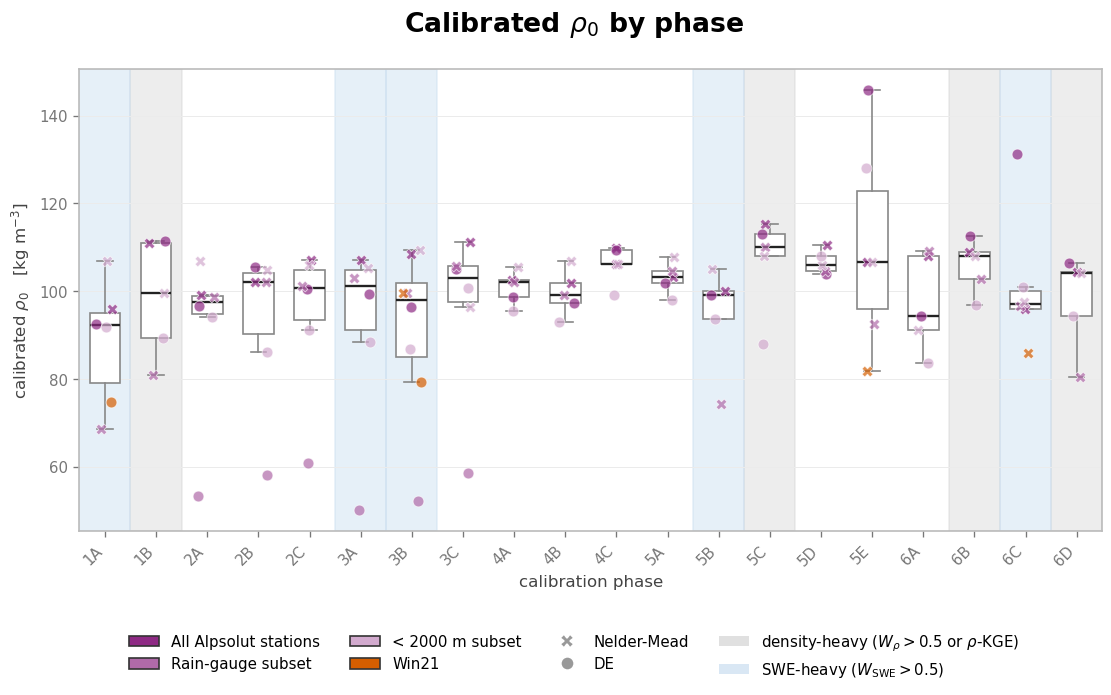

In [74]:
# Calibrated rho_0 (rho_null) by calibration phase: box per phase + overlaid runs.
# Background shading: density-heavy phases (W_rho > 0.5 OR any rho-KGE) in grey,
# SWE-heavy phases (W_swe > 0.5) in light blue.  (W_rho + W_swe = 1, so disjoint.)
dp = df.dropna(subset=["rho_null", "phase"]).copy()
phases = [p for p in PHASE_ORDER if p in dp["phase"].unique()]
pos = {p: i for i, p in enumerate(phases)}

# per-phase weights (fixed within a phase) -> "heavy" sets
_wr = ["w_RHO_NRMSE", "w_RHO_NBIAS", "w_RHO_KGE"]
_ws = ["w_SWE_NRMSE", "w_SWE_NBIAS", "w_SWE_KGE"]
wph = df.groupby("phase")[_wr + _ws].first()
wph["W_RHO"] = wph[_wr].sum(axis=1)
wph["W_SWE"] = wph[_ws].sum(axis=1)
heavy_rho = {p for p in phases if wph.loc[p, "W_RHO"] > 0.7 or wph.loc[p, "w_RHO_KGE"] > 0}
heavy_swe = {p for p in phases if wph.loc[p, "W_SWE"] > 0.7}

RHO_SHADE, SWE_SHADE = "#CCCCCC", "#C9DEF0"

fig, ax = plt.subplots(figsize=(max(10, 0.55 * len(phases)), 5))

# grey / blue background band for each density-heavy / SWE-heavy phase
for p in heavy_rho:
    ax.axvspan(pos[p] - 0.5, pos[p] + 0.5, color=RHO_SHADE, alpha=0.35, zorder=0)
for p in heavy_swe:
    ax.axvspan(pos[p] - 0.5, pos[p] + 0.5, color=SWE_SHADE, alpha=0.45, zorder=0)

# box per phase (white fill so it reads over the bands; points carry the colour)
box_data = [dp.loc[dp["phase"] == p, "rho_null"].to_numpy() for p in phases]
ax.boxplot(box_data, positions=range(len(phases)), widths=0.6,
           showfliers=False, patch_artist=True, zorder=2,
           boxprops=dict(facecolor="white", edgecolor="#888888"),
           whiskerprops=dict(color="#888888"), capprops=dict(color="#888888"),
           medianprops=dict(color=C.OBS, linewidth=1.4))

# individual runs, jittered, coloured by subset / marker by optimiser
for s in SUBSETS:
    for a in ALGOS:
        m = (dp["subset"] == s) & (dp["algorithm"] == a)
        if not m.any():
            continue
        xj = dp.loc[m, "phase"].map(pos).to_numpy() + rng.uniform(-0.18, 0.18, m.sum())
        ax.scatter(xj, dp.loc[m, "rho_null"], color=SUBSET_PALETTE[s],
                   marker=ALG_MARKERS[a], s=42, alpha=ALPHA.MARKER,
                   edgecolors="white", linewidths=0.5, zorder=3)

ax.set_xticks(range(len(phases)))
ax.set_xticklabels(phases, rotation=45, ha="right")
ax.set_xlim(-0.5, len(phases) - 0.5)
ax.set_xlabel("calibration phase")
ax.set_ylabel(r"calibrated $\rho_0$   [kg m$^{-3}$]")

shade_patches = [
    Patch(facecolor=RHO_SHADE, alpha=0.6, label=r"density-heavy ($W_\rho>0.5$ or $\rho$-KGE)"),
    Patch(facecolor=SWE_SHADE, alpha=0.7, label=r"SWE-heavy ($W_\mathrm{SWE}>0.5$)"),
]
alg_mark = [Line2D([0], [0], marker=ALG_MARKERS[a], linestyle="", markersize=8,
                   markerfacecolor=C.HS, markeredgecolor="white", label=a)
            for a in ALGOS]
fig.legend(handles=subset_handles() + alg_mark + shade_patches, loc="lower center",
           ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.16))
fig.suptitle(r"Calibrated $\rho_0$ by phase")
savefig(fig, "objfun_rho0_by_phase")
plt.show()
